In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

BASE_DIR = Path("..").resolve().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

plt.style.use("seaborn-v0_8-darkgrid")

In [2]:
batting = pd.read_csv(PROCESSED_DIR / "batting_features_final_v2.csv")
playing_xi = pd.read_csv(PROCESSED_DIR / "final_playing_xi.csv")

batting.head()

,batsman,runs,balls,dismissals,strike_rate,average,matches_played,Death,Middle,Powerplay,boundary_pct,dot_ball_pct,dismissal_rate,avg_pp_balls_per_match,avg_middle_balls_per_match,avg_death_balls_per_match
0,A Ashish Reddy,280,196,15,142.857143,18.666667,23,144.594595,148.780488,71.428571,55.000000,31.122449,13.066667,0.304348,1.782609,6.434783
1,A Badoni,963,740,36,130.135135,26.750000,46,152.522255,118.980170,58.000000,53.997923,35.270270,20.555556,1.086957,7.673913,7.326087
2,A Chandila,4,7,1,57.142857,4.000000,2,57.142857,NaN,NaN,0.000000,42.857143,7.000000,0.000000,0.000000,3.500000
3,A Chopra,53,75,5,70.666667,10.600000,6,50.000000,78.125000,65.853659,52.830189,60.000000,15.000000,6.833333,5.333333,0.333333
4,A Choudhary,25,20,2,125.000000,12.500000,3,125.000000,NaN,NaN,40.000000,20.000000,10.000000,0.000000,0.000000,6.666667


In [3]:
batters_in_xi = playing_xi[
    playing_xi["role"].isin(["Opener", "Middle Order", "Finisher"])
]["player"]

batting_xi = batting[batting["batsman"].isin(batters_in_xi)]
batting_xi

,batsman,runs,balls,dismissals,strike_rate,average,matches_played,Death,Middle,Powerplay,boundary_pct,dot_ball_pct,dismissal_rate,avg_pp_balls_per_match,avg_middle_balls_per_match,avg_death_balls_per_match
31,AB de Villiers,5181,3487,125,148.580442,41.448000,170,215.455594,129.246231,117.619048,61.262305,31.975911,27.896000,3.705882,11.705882,5.100000
248,JC Buttler,4121,2856,106,144.292717,38.877358,119,186.445013,140.362438,134.932054,66.537248,38.585434,26.943396,10.512605,10.201681,3.285714
285,KA Pollard,3437,2447,129,140.457703,26.643411,168,160.000000,120.391808,98.148148,64.823974,39.517777,18.968992,0.321429,6.684524,7.559524
570,SK Raina,5536,4177,168,132.535312,32.952381,200,165.257353,126.991333,128.925620,58.670520,35.336366,24.863095,6.050000,12.115000,2.720000
659,V Kohli,8671,6702,231,129.379290,37.536797,259,177.712264,122.370415,122.387476,55.910506,34.780662,29.012987,9.864865,12.737452,3.274131
693,YBK Jaiswal,2166,1454,62,148.968363,34.935484,66,200.000000,135.135135,154.484305,73.314866,40.784044,23.451613,13.515152,7.848485,0.666667


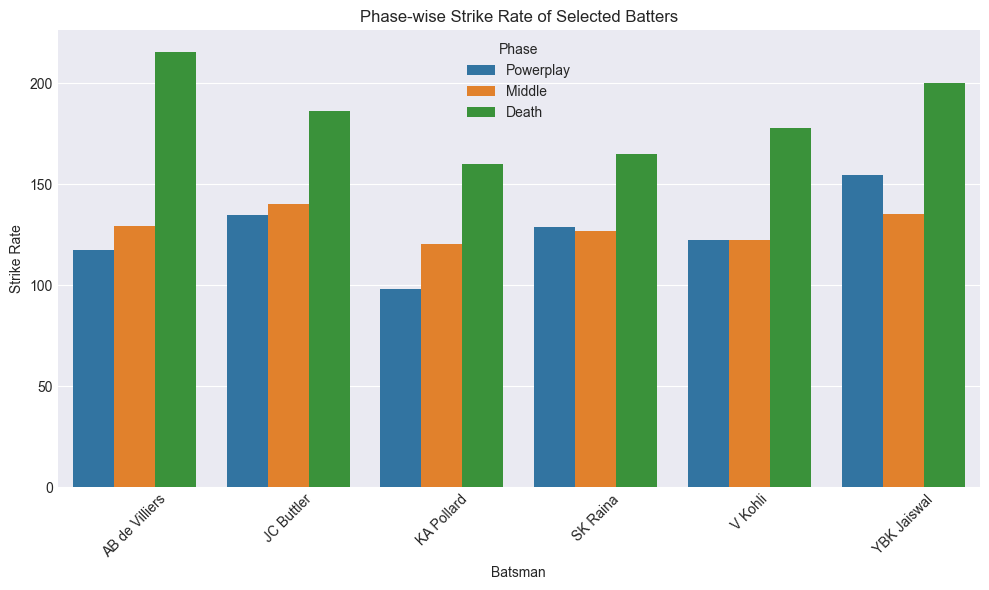

In [4]:
phase_cols = ["Powerplay", "Middle", "Death"]

batting_melted = batting_xi.melt(
    id_vars=["batsman"],
    value_vars=phase_cols,
    var_name="Phase",
    value_name="Strike Rate"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=batting_melted,
    x="batsman",
    y="Strike Rate",
    hue="Phase"
)

plt.title("Phase-wise Strike Rate of Selected Batters")
plt.xlabel("Batsman")
plt.ylabel("Strike Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

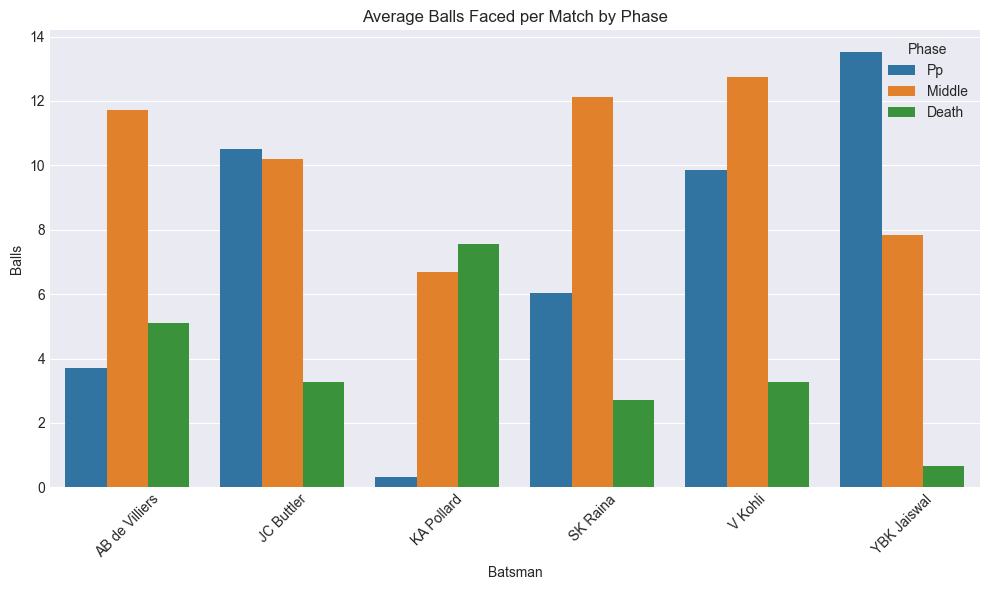

In [5]:
ball_cols = [
    "avg_pp_balls_per_match",
    "avg_middle_balls_per_match",
    "avg_death_balls_per_match"
]

balls_melted = batting_xi.melt(
    id_vars=["batsman"],
    value_vars=ball_cols,
    var_name="Phase",
    value_name="Balls per Match"
)

balls_melted["Phase"] = balls_melted["Phase"].str.replace(
    "avg_", ""
).str.replace("_balls_per_match", "").str.title()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=balls_melted,
    x="batsman",
    y="Balls per Match",
    hue="Phase"
)

plt.title("Average Balls Faced per Match by Phase")
plt.xlabel("Batsman")
plt.ylabel("Balls")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()